In [5]:
from statsbombpy import sb

In [2]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen
import numpy as np

## load in Statsbomb360 data remotely
parser = Sbopen()
frames, visible = parser.frame(3857288)

In [3]:
frames

,teammate,actor,keeper,match_id,id,x,y
0,True,False,False,3857288,5609159f-4c32-4da4-b63a-0df93eabd657,35.742849,34.371777
1,True,False,False,3857288,5609159f-4c32-4da4-b63a-0df93eabd657,37.408278,46.268930
2,True,False,False,3857288,5609159f-4c32-4da4-b63a-0df93eabd657,41.054832,21.401973
3,True,False,False,3857288,5609159f-4c32-4da4-b63a-0df93eabd657,46.062782,71.469765
4,True,False,False,3857288,5609159f-4c32-4da4-b63a-0df93eabd657,49.257424,37.712812
...,...,...,...,...,...,...,...
43272,False,False,False,3857288,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,61.448321,29.404478
43273,True,False,False,3857288,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,65.298295,49.452015
43274,True,False,False,3857288,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,65.829328,38.203990
43275,True,False,False,3857288,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,67.630456,29.920732


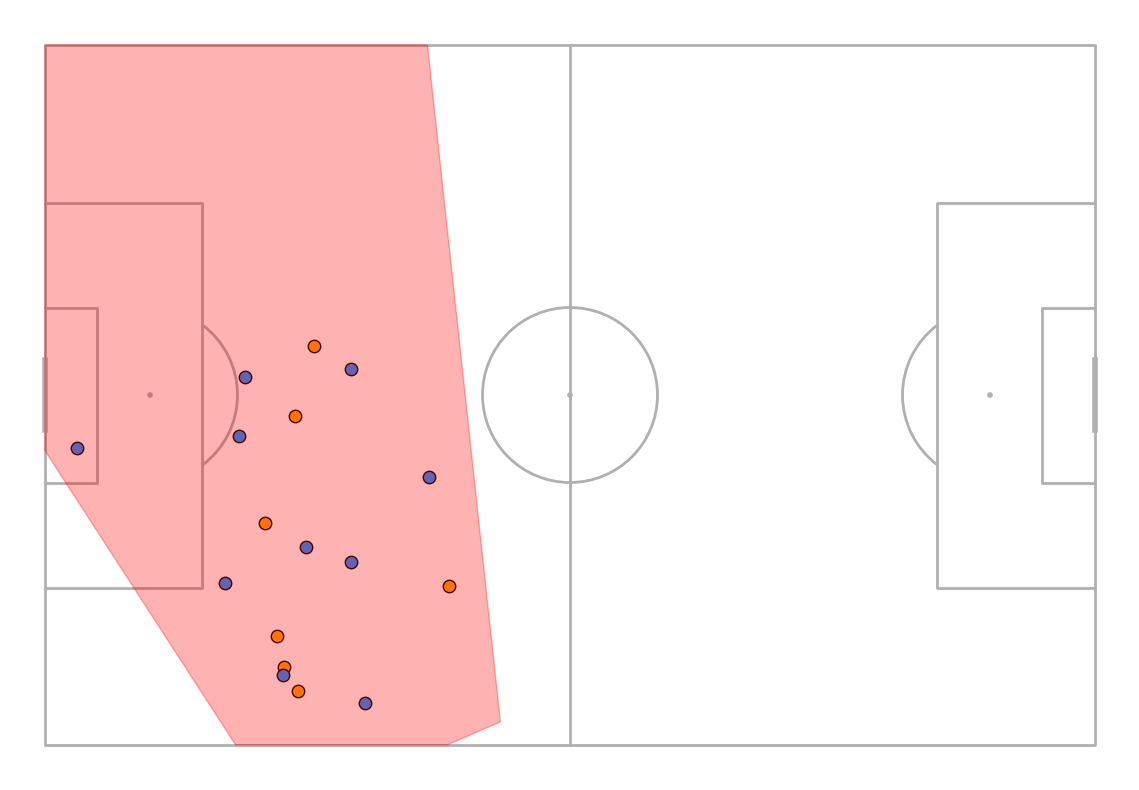

In [1]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen
import numpy as np

## load in Statsbomb360 data remotely
parser = Sbopen()
frames, visible = parser.frame(3857288)

## get plotting data
frame_idx = 50
frame_id = visible.iloc[50].id

visible_area = np.array(visible.iloc[frame_idx].visible_area).reshape(-1, 2)
player_position_data = frames[frames.id == frame_id]

teammate_locs = player_position_data[player_position_data.teammate]
opponent_locs = player_position_data[~player_position_data.teammate]

## set up pitch
p = Pitch(pitch_type='statsbomb')
fig, ax = p.draw(figsize=(12,8))

p.scatter(teammate_locs.x, teammate_locs.y, c='orange', s=80, ec='k', ax=ax)
p.scatter(opponent_locs.x, opponent_locs.y, c='dodgerblue', s=80, ec='k', ax=ax)
p.polygon([visible_area], color=(1, 0, 0, 0.3), ax=ax)

plt.show() ##to see the plot. You don't need this if you're using a jupyter notebook

In [6]:
competitions = sb.competitions()
competitions

g:\Meu Drive\football_data\notebooks\../statsbombpy\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-07-15T14:15:54.671676,2024-07-15T14:17:00.877356,2024-07-15T14:17:00.877356,2024-07-15T14:15:54.671676
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-06-13T07:51:02.452825,None,None,2024-06-13T07:51:02.452825
3,16,4,Europe,Champions League,male,False,False,2018/2019,2024-06-12T07:44:38.559714,2021-06-13T16:17:31.694,None,2024-06-12T07:44:38.559714
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-04-16T12:44:40.558402,2024-04-16T12:47:18.505110,2024-04-16T12:47:18.505110,2024-04-16T12:44:40.558402
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
72,72,107,International,Women's World Cup,female,False,True,2023,2024-07-14T16:59:48.469596,2024-07-14T17:01:38.887279,2024-07-14T17:01:38.887279,2024-07-14T16:59:48.469596


In [7]:
matches = sb.matches(competition_id=43, season_id=106)
matches


g:\Meu Drive\football_data\notebooks\../statsbombpy\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3857256,2022-12-02,21:00:00.000,International - FIFA World Cup,2022,Serbia,Switzerland,2,3,available,...,2023-04-26T23:49:58.956186,3,Group Stage,Stadium 974,Fernando Andrés Rapallini,Dragan Stojković,Murat Yakin,1.1.0,2,2
1,3869151,2022-12-03,21:00:00.000,International - FIFA World Cup,2022,Argentina,Australia,2,1,available,...,2023-07-30T07:48:51.865595,4,Round of 16,Ahmad bin Ali Stadium,Szymon Marciniak,Lionel Sebastián Scaloni,Graham James Arnold,1.1.0,2,2
2,3857257,2022-11-30,17:00:00.000,International - FIFA World Cup,2022,Australia,Denmark,1,0,available,...,2023-06-20T11:04:37.638969,3,Group Stage,Al Janoub Stadium,Mustapha Ghorbal,Graham James Arnold,Kasper Hjulmand,1.1.0,2,2
3,3857258,2022-11-24,21:00:00.000,International - FIFA World Cup,2022,Brazil,Serbia,2,0,available,...,2023-07-11T14:56:31.096588,1,Group Stage,Lusail Stadium,Alireza Faghani,Telê Santana da Silva,Dragan Stojković,1.1.0,2,2
4,3857288,2022-11-26,12:00:00.000,International - FIFA World Cup,2022,Tunisia,Australia,0,1,available,...,2023-04-27T00:30:07.835815,2,Group Stage,Al Janoub Stadium,Daniel Siebert,Jalel Kadri,Graham James Arnold,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,3857265,2022-11-22,18:00:00.000,International - FIFA World Cup,2022,Mexico,Poland,0,0,available,...,2023-04-27T00:49:30.005344,1,Group Stage,Stadium 974,Chris Beath,Gerardo Daniel Martino,Czesław Michniewicz,1.1.0,2,2
60,3857262,2022-12-02,17:00:00.000,International - FIFA World Cup,2022,South Korea,Portugal,2,1,available,...,2023-04-26T23:48:08.999798,3,Group Stage,Education City Stadium,Facundo Tello Figueroa,Paulo Jorge Gomes Bento,Fernando Manuel Fernandes da Costa Santos,1.1.0,2,2
61,3857261,2022-11-29,21:00:00.000,International - FIFA World Cup,2022,Wales,England,0,3,available,...,2023-04-27T00:02:44.241621,3,Group Stage,Ahmad bin Ali Stadium,Slavko Vinčić,Robert Page,Gareth Southgate,1.1.0,2,2
62,3857255,2022-12-01,21:00:00.000,International - FIFA World Cup,2022,Japan,Spain,2,1,available,...,2023-04-26T23:51:48.352990,3,Group Stage,Sheikh Khalifa International Stadium,Victor Miguel de Freitas Gomes,Hajime Moriyasu,Luis Enrique Martínez García,1.1.0,2,2


In [17]:
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'match_week',
       'competition_stage', 'stadium', 'referee', 'home_managers',
       'away_managers', 'data_version', 'shot_fidelity_version',
       'xy_fidelity_version'],
      dtype='object')

In [13]:
events = sb.events(match_id=3857288)
events.head()

g:\Meu Drive\football_data\notebooks\../statsbombpy\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Tunisia,777,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Australia,792,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Tunisia,777,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Australia,792,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Australia,792,00:00:00.000,Half Start,NaN


In [16]:
events.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'block_deflection', 'carry_end_location', 'clearance_aerial_won',
       'clearance_body_part', 'clearance_head', 'clearance_left_foot',
       'clearance_other', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location',
       'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_deflected', 'pass_end_locatio

In [ ]:
frames = sb.frames(match_id=3857288)
frames

g:\Meu Drive\football_data\notebooks\../statsbombpy\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,id,visible_area,match_id,teammate,actor,keeper,location
0,5609159f-4c32-4da4-b63a-0df93eabd657,"[80.946248881448, 80.0, 39.0173344032844, 80.0...",3857288,True,False,False,"[35.74284928699146, 34.371776801222715]"
1,5609159f-4c32-4da4-b63a-0df93eabd657,"[80.946248881448, 80.0, 39.0173344032844, 80.0...",3857288,True,False,False,"[37.40827753407489, 46.268930325497266]"
2,5609159f-4c32-4da4-b63a-0df93eabd657,"[80.946248881448, 80.0, 39.0173344032844, 80.0...",3857288,True,False,False,"[41.05483197355897, 21.401972880850256]"
3,5609159f-4c32-4da4-b63a-0df93eabd657,"[80.946248881448, 80.0, 39.0173344032844, 80.0...",3857288,True,False,False,"[46.06278156490877, 71.4697653362788]"
4,5609159f-4c32-4da4-b63a-0df93eabd657,"[80.946248881448, 80.0, 39.0173344032844, 80.0...",3857288,True,False,False,"[49.25742379717195, 37.71281185609556]"
...,...,...,...,...,...,...,...
43272,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,"[14.6822206487139, 80.0, 39.8423876814832, 11....",3857288,False,False,False,"[61.44832080334071, 29.404478324707583]"
43273,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,"[14.6822206487139, 80.0, 39.8423876814832, 11....",3857288,True,False,False,"[65.29829530005031, 49.45201504356663]"
43274,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,"[14.6822206487139, 80.0, 39.8423876814832, 11....",3857288,True,False,False,"[65.82932840153144, 38.20398969102791]"
43275,f249d150-b9b1-4bef-a87e-b2b5713d4e4c,"[14.6822206487139, 80.0, 39.8423876814832, 11....",3857288,True,False,False,"[67.63045620632573, 29.92073190775632]"
